In [1]:
import os

from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
from tqdm import tqdm
from glob import glob

import mdtraj as md

from mdentropy.metrics import DihedralMutualInformation
from mdentropy import nmutinf

In [2]:
LOAD_SAVED_RESULTS = True
SAVED_PATH = "/home/tjlane/scratch/mpro/notebook_scratch/"

# mutual information predictors

## dihedral and Ca backbone MI

In [3]:
def chi1_dihedral_MI(traj, shuffle=1, n_bins=16):
    mi = DihedralMutualInformation(n_bins=n_bins, types=['chi1'], method='knn', threads=32, normed=False)
    M = mi.partial_transform(traj, shuffle=shuffle, verbose=True)
    return M


def c_alpha_MI(traj):
    
    idx  = traj.top.select('name == CA')
    traj = traj.atom_slice(idx)
    
    n = traj.n_atoms

    mi = np.zeros([n, n])

    for i in tqdm(range(n)):
        for j in range(i, n):
    
            mi_ij = nmutinf(8, traj.xyz[:,i,:], traj.xyz[:,j,:])
            mi[i,j] = mi_ij
            mi[j,i] = mi_ij
    
    return mi

## Compute mutual information under the gaussian approximation 

Let $x_i$ and $x_j$ be the xyz vectors for two atoms, which we assume are MVN distributed.

Then the mutual information between $p(x_i)$ and $p(x_j)$ is

$$
I(X_i, X_j) = \frac{1}{2} \ln \left( \frac{| \Sigma_i || \Sigma_j |}{|\Sigma|} \right)
$$

where $\Sigma$ is the 6x6 combined covariance matrix.

In [4]:
def mvn_MI(traj):
    
    xyz = traj.xyz
    
    assert len(xyz.shape) == 3  # (frames, atoms, x/y/z)
    n_atoms = xyz.shape[1]
    
    
    mutinf = np.zeros([n_atoms, n_atoms])
    
    # FIRST compute all Sigma_ij
    #
    # the covariance matrix (S here) is the 
    # outer product across atom indices, and x/y/z 
    # summed across frames, normalized like covariance
    #
    #      (frames, atoms, xyz)
    #  X       a      i     k
    #  X2      a      j     l
    
    xyz_centered = xyz - np.mean(xyz, axis=0)[None,:,:]
    assert xyz_centered.shape == xyz.shape, xyz_centered.shape
    S = np.einsum('aik,ajl->ijkl', xyz_centered, xyz_centered)
    S = S / float(xyz.shape[0] - 1)

    
    # first, compute all the 3x3 determinants  
    S_diag = np.einsum('iijk->ijk', S)
    assert S_diag.shape == (n_atoms, 3, 3)
    
    signs, log_Sdet = np.linalg.slogdet(S_diag)
    assert log_Sdet.shape == (n_atoms,)
        
    # covariances should be psd
    assert np.all(signs > 0.1) 
    
    for i in range(n_atoms):
        for j in range(i+1, n_atoms):
            
            S_ij = np.block([ [ S[i,i], S[i,j] ],
                              [ S[j,i], S[j,j] ] ])
            sign, log_Sdet_ij = np.linalg.slogdet(S_ij)
            
            if sign == 0.0:
                mi = 0
                print('singular S matrix')
            elif sign < 0.0:
                raise RuntimeError('negative determinant')
            else:            
                mi = 0.5 * (log_Sdet[i] + log_Sdet[j] - log_Sdet_ij)
                
                mutinf[i,j] = mi
                mutinf[j,i] = mi
    
    return mutinf


def bootstrap_mi(traj, n_samples=10, debug=False):
    
    xyz = traj.xyz
    
    if debug:
        sigmas = np.zeros([n_samples, xyz.shape[1], xyz.shape[1]])
    
    # running variance estimate
    # https://www.johndcook.com/blog/standard_deviation/
    
    for k in range(n_samples):
        
        smpl_idx = np.random.randint(0, xyz.shape[0], size=xyz.shape[0])
        smpl = xyz[smpl_idx,:,:]
        
        x = mvn_mutinf(smpl)
        
        if debug:
            sigmas[k] = x
        
        if k == 0:
            M_km1 = x
            S_km1 = np.zeros_like(x)
        else:
            M_k = M_km1 + (x-M_km1) / (k+1)
            S_k = S_km1 + (x-M_km1) * (x-M_k)
            M_km1 = M_k
            S_km1 = S_k
        
    if debug:
        resi = 55
        print(np.sqrt(S_k / k)[resi,resi])
        print(np.std(sigmas[:,resi,resi]))
    
    return np.sqrt(S_k / k)

## Conditional Displacement

Assume we have a MVN distribution for vector $x$. If $x$ is partitioned into $x = [x_1, x_2]$, then the conditional distribution $(x_1|x_2 = a) ~ N(\bar{\mu}, \bar{\Sigma})$ with mean

$$
\bar{\mu} = \mu_1 + \Sigma_{12} \Sigma_{22}^{-1} (a - \mu_2)
$$
or in terms of displacements $\delta$,
$$
\delta_1 = \Sigma_{12} \Sigma_{22}^{-1} \delta_2
$$
the squared Eucledian distance of $\delta_1$ is
$$
\delta_1^T \delta_1 = \delta_2^T \Sigma_{22}^{-1} \Sigma_{21} \Sigma_{12} \Sigma_{22}^{-1} \delta_2
$$
the matrix $A = \Sigma_{22}^{-1} \Sigma_{21} \Sigma_{12} \Sigma_{22}^{-1}$ is PSD so admits an eigendecomposition $A = U^{-1} \Lambda U$, with unitary $U$. Let $x' = U \delta_2$ so that
$$
\delta_1^T \delta_1 = x'^{T} \Lambda x' = \sum_{\alpha=1}^3 \lambda_{\alpha} x'^2_{\alpha}
$$
if we consider $\delta_1^T \delta_1$ to be a constant, then this is the equation for an ellipsoid in 3 dimensions.

In spherical coordinates for $x'$,
$$
\delta_1^T \delta_1 =
\frac{r^2 \cos^2 \theta \sin^2 \phi}{\sqrt{\lambda_1}} +
\frac{r^2 \sin^2 \theta \sin^2 \phi}{\sqrt{\lambda_2}} +
\frac{r^2 \cos^2 \phi}{\sqrt{\lambda_3}}
$$
by averaging, ie intergation with $\frac{1}{4 \pi} \int_{0}^{2 \pi} \int_{0}^{\pi} \sin \phi \ d\phi \ d\theta$, one obtains
$$
\delta_1^T \delta_1 = \frac{r^2}{3} \sum_\alpha \lambda_\alpha^{-1/2}
$$
We define the "conditional displacement" as the ratio of of the two lengths
$$
\frac{r_1}{r_2} = \sqrt{ \frac{1}{3} Tr \left\{ \Lambda^{-1/2} \right\} }
$$

References:
Eaton, Morris L. (1983). Multivariate Statistics: a Vector Space Approach. John Wiley and Sons. pp. 116–117. ISBN 978-0-471-02776-8.
https://en.wikipedia.org/wiki/Multivariate_normal_distribution#Conditional_distributions

In [29]:
def conditional_displacement(traj, norm=False):
    
    idx  = traj.top.select('name == CA')
    traj = traj.atom_slice(idx)
    xyz = traj.xyz
    
    assert len(xyz.shape) == 3  # (frames, atoms, x/y/z)
    n_atoms = xyz.shape[1]
    
    # ALGORITHM
    #
    # for all pairs of i > j:
    #     1. compute B_ij = Sigma_ij Sigma_jj^-1
    #     2. perform SVD of B_ij, compute b_ij -> sum{singular_values}
    #     3. CD_ij -> sqrt{ (4*pi/3) * b_ij }
    #
    # Note: there is probably a more efficient way...
    
    cd = np.zeros([n_atoms, n_atoms])
    
    # FIRST compute all Sigma_ij
    #
    # the covariance matrix (S here) is the 
    # outer product across atom indices, and x/y/z 
    # summed across frames, normalized like covariance
    #
    #      (frames, atoms, xyz)
    #  X       a      i     k
    #  X2      a      j     l
    
    xyz_centered = xyz - np.mean(xyz, axis=0)[None,:,:]
    assert xyz_centered.shape == xyz.shape, xyz_centered.shape
    S = np.einsum('aik,ajl->ijkl', xyz_centered, xyz_centered)
    S = S / float(xyz.shape[0] - 1)
    
    # SECOND compute B_ij and do the SVD
    
    const = (1.0 / 3.0)
    for j in range(n_atoms):
        
        S_jj_inv = np.linalg.inv(S[j,j])
        
        for i in range(n_atoms):
            
            B_ij = np.matmul(S[i,j], S_jj_inv)
            sv = np.linalg.svd(B_ij,
                               compute_uv=False, 
                               hermitian=True)
            b_ij = np.sum(sv)
            r = np.sqrt(const * b_ij)
            cd[i,j] = r
    
    return cd


def bootstrap_CD(traj, n_samples=10, debug=False):
    
    xyz = traj.xyz
    
    if debug:
        sigmas = np.zeros([n_samples, xyz.shape[1], xyz.shape[1]])
    
    # running variance estimate
    # https://www.johndcook.com/blog/standard_deviation/
    
    for k in range(n_samples):
        
        smpl_idx = np.random.randint(0, xyz.shape[0], size=xyz.shape[0])
        smpl = xyz[smpl_idx,:,:]
        
        x = conditional_displacement(smpl)
        
        if debug:
            sigmas[k] = x
        
        if k == 0:
            M_km1 = x
            S_km1 = np.zeros_like(x)
        else:
            M_k = M_km1 + (x-M_km1) / (k+1)
            S_k = S_km1 + (x-M_km1) * (x-M_k)
            M_km1 = M_k
            S_km1 = S_k
        
    if debug:
        resi = 55
        print(np.sqrt(S_k / k)[resi,resi])
        print(np.std(sigmas[:,resi,resi]))
    
    return np.sqrt(S_k / k)

## -- load structures, we need all atoms --

In [6]:
ATOM_SELECTION = '(element != H) and is_protein and (resi < 303) and (resi > 1)'

def load_pdbs_all_atoms(glob_pattern):
    
    crystals = None

    files_to_load = sorted(glob(glob_pattern))
    
    for pdb in tqdm(files_to_load):

        try:

            trj = md.load_pdb(pdb)
            idx = trj.top.select(ATOM_SELECTION)
            trj = trj.atom_slice(idx)

            if crystals:
                crystals = crystals.join(trj, check_topology=False)
            else:
                crystals = trj
                
        except Exception as exptn:
            print(trj.xyz.shape)
            print(crystals.xyz.shape)
            print("something went wrong", pdb, exptn)


    crystals = crystals.center_coordinates()
    
    return crystals

In [7]:
crystals = load_pdbs_all_atoms('../../allostery/selected_dataset_archive_2023-01-14/pdb/*.pdb')

crystals_filename = SAVED_PATH + "mutinf_crystals.h5"
if LOAD_SAVED_RESULTS:
    crystals = md.load_hdf5(crystals_filename)
else:
    crystals.save_hdf5(crystals_filename)

100%|██████████| 1146/1146 [06:16<00:00,  3.05it/s]


In [8]:
# each dcd file is 1000 frames with 1ns spacing between frames
SUBSAMPLE     = 10

prefix = '/asap3/petra3/gpfs/p11/2020/data/11009999/shared/mdsim/DESRES-Trajectory_sarscov2-10880334-no-water-no-ion-glueCA'
md_files = sorted(glob(prefix + '/sarscov2-10880334-no-water-no-ion-glueCA/*.dcd'))

top_path = prefix + '/system_nowat.pdb'

md_sim = None

for f in tqdm(md_files):

    t = md.load(f, top=top_path)[::SUBSAMPLE]
    idx = t.top.select(ATOM_SELECTION)
    t   = t.atom_slice(idx)

    if md_sim == None:
        md_sim = t
    else:
        md_sim += t

md_sim = md_sim.center_coordinates()

100%|██████████| 100/100 [01:39<00:00,  1.00it/s]


In [9]:
diamond = load_pdbs_all_atoms('/asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/*.pdb')

diamond_filename = SAVED_PATH + "mutinf_diamond.h5"
if LOAD_SAVED_RESULTS:
    diamond = md.load_hdf5(diamond_filename)
else:
    diamond.save_hdf5(diamond_filename)

print(len(diamond))

 57%|█████▋    | 60/105 [00:17<00:12,  3.48it/s]

(1, 2319, 3)
(59, 2330, 3)
something went wrong /asap3/petra3/gpfs/p11/2020/data/11009999/shared/diamond_05-May-2020/Mpro-x1187_0.pdb Number of atoms in self (2330) is not equal to number of atoms in other


100%|██████████| 105/105 [00:31<00:00,  3.36it/s]

104


In [25]:
print(crystals.xyz.shape)
print(md_sim.xyz.shape)
print(diamond.xyz.shape)

(1146, 2330, 3)
(10000, 2330, 3)
(104, 2330, 3)


In [11]:
active_site_residues = np.array([41, 49, 143, 144, 145, 163, 164, 165, 166, 167, 187, 188, 189, 190, 191, 192]) - 1

# -- compute info stat and project onto active site --

In [12]:
STATISTIC = "conditional_displacement"

In [31]:
if STATISTIC == "chi1_dihedral_MI":
    statistic_transform_function = chi1_dihedral_MI
    plot_title = r"$\chi_1$ mutual information"
    
elif STATISTIC == "c_alpha_MI":
    statistic_transform_function = c_alpha_MI
    plot_title = r"$C_{\alpha}$ mutual information"
    
elif STATISTIC == "mvn_MI":
    statistic_transform_function = mvn_MI
    plot_title = r"MVN mutual information"
    
elif STATISTIC == "conditional_displacement":
    statistic_transform_function = conditional_displacement
    plot_title = r"conditional displacement"

else:
    raise ValueError(f"unknown: {STATISTIC}")

In [37]:
def load_or_compute_statistic(traj, traj_name):
    filename = SAVED_PATH + f"mutinf_{traj_name}_{STATISTIC}.npy"
    if LOAD_SAVED_RESULTS and os.path.exists(filename):
        M = np.load(filename)
    else:
        M = statistic_transform_function(traj)
        np.save(filename, M)
    return M
        
    
M_xtal = load_or_compute_statistic(crystals, "crystals")
M_md   = load_or_compute_statistic(md_sim, "md_sim")
M_dmnd = load_or_compute_statistic(diamond, "diamond")
    
print(M_xtal.shape, M_md.shape, M_dmnd.shape)

(301, 301) (301, 301) (301, 301)


## visualize residue-to-residue cov

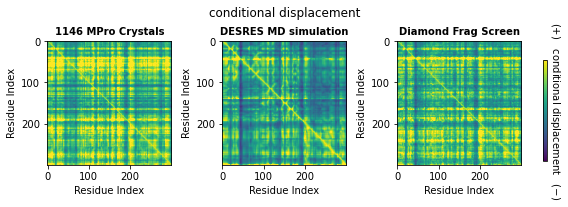

In [33]:
scale = 1 # how much to zoom colorbar
md_scale = 1
ticks = np.arange(0, 260, 100)
cmap = 'viridis'


fig = plt.figure(figsize=(8,3))
fig.suptitle(plot_title)

gs1 = gridspec.GridSpec(1, 3)

ax1 = fig.add_subplot(gs1[0])
ax2 = fig.add_subplot(gs1[1])
ax3 = fig.add_subplot(gs1[2])

ax1.set_title('%d MPro Crystals' % crystals.n_frames, 
              fontweight='bold', fontsize=10)
im = ax1.imshow(M_xtal, cmap=cmap, 
                vmin=0, vmax=scale)

ax1.set_xticks(ticks)
ax1.set_xticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax1.set_yticks(ticks)
ax1.set_yticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax1.set_xlabel('Residue Index')
ax1.set_ylabel('Residue Index')

if md_scale == 1:
    ax2.set_title(f'DESRES MD simulation', 
              fontweight='bold', fontsize=10)
else:
    ax2.set_title(f'DESRES MD simulation (x{md_scale})', 
                  fontweight='bold', fontsize=10)
ax2.imshow(M_md[:M_xtal.shape[0],:M_xtal.shape[1]], cmap=cmap, 
           vmin=0, vmax=scale / md_scale)

ax2.set_xticks(ticks)
ax2.set_xticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax2.set_yticks(ticks)
ax2.set_yticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax2.set_xlabel('Residue Index')
ax2.set_ylabel('Residue Index')


ax3.set_title('Diamond Frag Screen', 
              fontweight='bold', fontsize=10)
ax3.imshow(M_dmnd, cmap=cmap, 
           vmin=0, vmax=scale)

ax3.set_xticks(ticks)
ax3.set_xticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax3.set_yticks(ticks)
ax3.set_yticklabels([str(int(t)) for t in ticks]) # div by 2 for Ca AND Cb atoms
ax3.set_xlabel('Residue Index')
ax3.set_ylabel('Residue Index')


cbar_div = 0.93          # fraction not taken by cbar
cbar_height_pad = 0.18   # smaller = bigger cbar

gs1.tight_layout(fig, rect=[0, 0, cbar_div, 1])

gs2 = gridspec.GridSpec(1, 1)
cax = fig.add_subplot(gs2[0])
cbar = plt.colorbar(im, cax=cax)
cbar.set_ticks([])
cbar.set_label(f'$(+)$   {plot_title}   $(-)$', rotation=270, labelpad=15)
gs2.tight_layout(fig, rect=[cbar_div, cbar_height_pad, 1, 1-cbar_height_pad])

plt.savefig(f'figures/{STATISTIC}_matrix.pdf')
plt.show()

## plot projection onto active site

In [34]:
M_mu_xtal  = np.abs(M_xtal.T[active_site_residues,:]).mean(0)
M_std_xtal = np.abs(M_xtal.T[active_site_residues,:]).std(0)

In [35]:
y_shift = 0.01
ymin = M_mu_xtal.min() - M_std_xtal.mean() / 2
ymax = M_mu_xtal.max() + M_std_xtal.mean() / 2

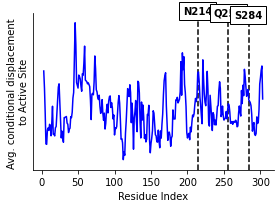

In [38]:
res_idx = np.arange(M_mu_xtal.shape[0]) + 3


plt.figure(figsize=(4,3))

ax1 = plt.subplot(111)

ax1.plot(res_idx, M_mu_xtal, color='b')

# ax1.fill_between(res_idx, M_mu_xtal - err_mu_xtal * 3, mu_xtal + err_mu_xtal * 3, 
#                 alpha=0.3, color='grey')

ax1.set_xlabel(r'Residue Index')
ax1.set_ylabel(f'Avg. {plot_title} \nto Active Site')
ax1.set_yticks([])

# crystal contacts
cont = ax1.vlines(24, -0.0002, 0.0001, color='r')
ax1.vlines(60, -0.0002, 0.0001, color='r')
ax1.vlines(222, -0.0002, 0.0001, color='r')

# active site residues
for r in active_site_residues:
    act = ax1.vlines(r+3, -0.0002, 0.0001)

# interesting
bbox = dict(facecolor='white', edgecolor='black')
ax1.text(194, ymax - y_shift, 'N214', weight='bold', bbox=bbox)
ax1.text(236, ymax - 2*y_shift, 'Q256', weight='bold', bbox=bbox)
ax1.text(264, ymax - 3*y_shift, 'S284', weight='bold', bbox=bbox)

ax1.vlines(214, ymin, ymax, linestyles="--")
ax1.vlines(256, ymin, ymax, linestyles="--")
ax1.vlines(284, ymin, ymax, linestyles="--")

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax1.set_ylim([ymin, ymax])
    
#plt.legend([act, cont], ['active site', 'crystal contact'], loc=2)
    
plt.tight_layout()
plt.savefig(f'figures/{STATISTIC}_to_active_site.pdf')
plt.show()